X_train shape: (25, 5)
X_test shape: (7, 5)
y_train shape: (25,)
y_test shape: (7,)


C:\Users\student\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 1.000


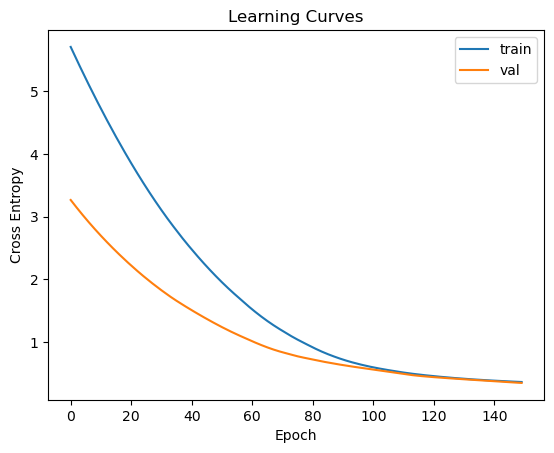

In [2]:
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

from matplotlib import pyplot
df = read_csv('Iris.csv')
X = df.values[:, :-1]
y = df.values[:, -1]
X = X.astype('float32')
y = LabelEncoder().fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    random_state=123
)
print("X_train shape: {}".format(X_train.shape))
print("X_test shape: {}".format(X_test.shape))
print("y_train shape: {}".format(y_train.shape))
print("y_test shape: {}".format(y_test.shape))

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=1
)
n_features = X_train.shape[1]

model = Sequential()

model.add(
    Dense(
        10,
        activation='relu',
        kernel_initializer='he_normal',
        input_shape=(n_features,)
    )
)

model.add(
    Dense(
        8,
        activation='relu',
        kernel_initializer='he_normal'
    )
)

model.add(
    Dense(
        3,
        activation='softmax'
    )
)
sgd = SGD(
    learning_rate=0.001,
    momentum=0.8
)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=32,
    verbose=0,
    validation_split=0.3
)
loss, acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print('Test Accuracy: %.3f' % acc)
pyplot.title('Learning Curves')

pyplot.xlabel('Epoch')

pyplot.ylabel('Cross Entropy')

pyplot.plot(
    history.history['loss'],
    label='train'
)

pyplot.plot(
    history.history['val_loss'],
    label='val'
)

pyplot.legend()

pyplot.show()